# Part 2: Integrating Parkinson's disease cohorts

This notebook is a continuation of demoing the utility of `mgnipy` in curating cross-study datasets from MGnify for secondary analysis. 

Here we further preprocess the curated dataset we obtained from Part 1. Specifically we preprocess the count data and then use `ABaCo` for batch/technical variance correction, following [their PD demo](https://mona-abaco.readthedocs.io/en/latest/tutorial/demo-parkinson.html)

Using abaco we aim to mitigate the technical variance across the 6 MGnify studies.

```{margin}
After clicking the "Activate Notebook" button you can run the cells in this browser. Alternatively, you can also click on the 🚀 to launch in colab or binder.
```
<button title="Make live" style="display:inline-flex;align-items:center;gap:0.4rem;padding:0.5rem 1rem;border:0;border-radius:20px;background:linear-gradient(135deg,#0f766e,#14b8a6);color:white;cursor:pointer;font-size:1rem;" class="thebe-button" onclick="initThebeSBT()">Activate Notebook</button>

---

In [1]:
# uncomment if colab
# !pip install abaco

## Loading the dataset from Part 1

In [2]:
import anndata as ad 
# read in
ad_tax = ad.read_h5ad('pd.h5ad')
# check it out
ad_tax

AnnData object with n_obs × n_vars = 1606 × 3247
    obs: 'experiment_type', 'instrument_model', 'instrument_platform', 'sample_accession', 'study_accession', 'updated_at', 'run_accession', 'status', 'pipeline_version', 'sample__accession', 'sample__ena_accessions', 'sample__sample_title', 'sample__biome', 'sample__updated_at', 'study__accession', 'study__ena_accessions', 'study__title', 'study__updated_at', 'study__biome.biome_name', 'study__biome.lineage', 'study__metadata.study_name', 'study__metadata.center_name', 'study__metadata.study_title', 'study__metadata.study_accession', 'study__metadata.study_description', 'study__metadata.secondary_study_accession', 'GivenID', 'RunID', 'SRA accession', 'name', 'taxid', 'ENA first public', 'ENA-CHECKLIST', 'External Id', 'INSDC center name', 'INSDC last update', 'INSDC status', 'Submitter Id', 'broad-scale environmental context', 'collection date', 'description', 'environmental medium', 'geographic location (country and/or sea)', 'geograph

## Preprocessing the counts

and we will agglomerate to Genus level

In [3]:
import numpy as np
import scanpy as sc
from mgnipy._models.constants.tax_ranks import SILVA_TAX_RANKS

# quick cleaning

# add filled na layer, zeros
ad_tax.layers["filled_na"] = ad_tax.to_df().fillna(0)

# drop samples if library count is less than median
ad_filt = ad_tax[
    ad_tax.to_df(layer="filled_na").sum(axis=1)
    >= ad_tax.to_df(layer="filled_na").sum(axis=1).median()
]

print(f"Num samples after filtering for low library counts: {ad_filt.n_obs}")

# agglom to genus level (pruning then agg)
pruned = ad_filt[:, ((ad_filt.var["Genus"] != "NA") & (ad_filt.var["Species"] != "NA"))]

# to avoid memory issues..
pruned.var["ranks_to_genus"] = pruned.var[SILVA_TAX_RANKS[:-1]].agg(";".join, axis=1)
# agg with scanpy
ad_genus = sc.get.aggregate(
    pruned,
    by="ranks_to_genus",
    func="sum",
    axis="var",
    layer="filled_na",
)

print(f"Num features after agglomerating to genus level (w/ pruning): {ad_genus.n_vars}")

# genus prevalence threshold of 10% samples
ad_genus_filt = ad_genus[
    :, (ad_genus.to_df(layer="sum") > 0).sum(axis=0) >= (ad_genus.n_vars * 0.1)
]

print(f"Num features after filtering for prevalence threshold of 10%: {ad_genus_filt.n_vars}")

# now to relative abundances
ad_genus_filt.obs["total_counts"] = ad_genus_filt.layers["sum"].sum(axis=1)
ad_genus_filt.layers["total_counts"] = np.array([ad_genus_filt.obs["total_counts"]] * ad_genus_filt.n_vars).T
ad_genus_filt.layers["rel_abund"] = ad_genus_filt.layers["sum"] / ad_genus_filt.layers["total_counts"]

#verbose
print(ad_genus_filt)
print(ad_genus_filt.obs['has_parkinsons_disease'].value_counts())

Num samples after filtering for low library counts: 803
Num features after agglomerating to genus level (w/ pruning): 465
Num features after filtering for prevalence threshold of 10%: 84
AnnData object with n_obs × n_vars = 803 × 84
    obs: 'experiment_type', 'instrument_model', 'instrument_platform', 'sample_accession', 'study_accession', 'updated_at', 'run_accession', 'status', 'pipeline_version', 'sample__accession', 'sample__ena_accessions', 'sample__sample_title', 'sample__biome', 'sample__updated_at', 'study__accession', 'study__ena_accessions', 'study__title', 'study__updated_at', 'study__biome.biome_name', 'study__biome.lineage', 'study__metadata.study_name', 'study__metadata.center_name', 'study__metadata.study_title', 'study__metadata.study_accession', 'study__metadata.study_description', 'study__metadata.secondary_study_accession', 'GivenID', 'RunID', 'SRA accession', 'name', 'taxid', 'ENA first public', 'ENA-CHECKLIST', 'External Id', 'INSDC center name', 'INSDC last updat

/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_51436/3989967467.py:22: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  pruned.var["ranks_to_genus"] = pruned.var[SILVA_TAX_RANKS[:-1]].agg(";".join, axis=1)
/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_51436/3989967467.py:42: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_genus_filt.obs["total_counts"] = ad_genus_filt.layers["sum"].sum(axis=1)
/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_51436/3989967467.py:44: RuntimeWarning: invalid value encountered in divide
  ad_genus_filt.layers["rel_abund"] = ad_genus_filt.layers["sum"] / ad_genus_filt.layers["total_counts"]


preparing dataset for ABaCo, which requires the feature cols but also:
- ids
- batch labels (pipeline version)
- bio group labels (disease status)

In [4]:
df_ab = (
    ad_genus_filt.obs[["has_parkinsons_disease", "pipeline_version"]]
    .merge(ad_genus_filt.to_df(layer="sum"), left_index=True, right_index=True)
    .reset_index()
)
df_ab.to_csv("pd_gut_genus.csv", index=False)
df_ab.head()

,_mgnipy_runs_accs,has_parkinsons_disease,pipeline_version,Bacteria;NA;Actinobacteria;Coriobacteriia;Coriobacteriales;Coriobacteriaceae;Collinsella,Bacteria;NA;Actinobacteria;Coriobacteriia;Eggerthellales;Eggerthellaceae;Raoultibacter,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Alloscardovia,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Bifidobacterium,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Parascardovia,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Scardovia,Bacteria;NA;Actinomycetota;Actinomycetes;Kitasatosporales;Streptomycetaceae;Streptomyces,...,Root;Bacteria;Bacteroidetes;Bacteroidia;Bacteroidales;Rikenellaceae;Alistipes,Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Lachnospiraceae;Blautia,Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Lachnospiraceae;Coprococcus,Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Lachnospiraceae;Dorea,Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Lachnospiraceae;Roseburia,Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Lachnospiraceae;[Ruminococcus],Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Ruminococcaceae;Faecalibacterium,Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Ruminococcaceae;Ruminococcus,Root;Bacteria;Firmicutes;Clostridia;Clostridiales;Veillonellaceae;Veillonella,Root;Bacteria;Firmicutes;Erysipelotrichi;Erysipelotrichales;Erysipelotrichaceae;[Eubacterium]
0,ERR2730148,N,v6,0.0,0.0,0.0,590.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ERR2730149,N,v6,0.0,0.0,0.0,1836.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERR2730150,N,v6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ERR2730151,N,v6,0.0,0.0,1.0,116.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ERR2730152,N,v6,0.0,0.0,0.0,31.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Batch correction with `ABaCo`

the below code is from [their demo notebook](https://mona-abaco.readthedocs.io/en/latest/tutorial/demo-parkinson.html)

In [5]:
from abaco.dataloader import DataPreprocess

# Load Parkinson's disease dataset
path_to_dataset = "pd_gut_genus.csv"
batch_col = "pipeline_version"
bio_col = "has_parkinsons_disease"
id_col = "_mgnipy_runs_accs"

# Convert data path into compatible pd.DataFrame
df_parkinson = DataPreprocess(
    path_to_dataset, factors=[id_col, batch_col, bio_col]
).dropna()

In [6]:
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova
from skbio.stats.ordination import pcoa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Auxiliary
def permanova_ait(df, sample_label, group_label):
    samples = df[sample_label].values
    groups = df[group_label].values
    clr_data = df.select_dtypes(include="number").values

    aitch = pdist(clr_data, metric="euclidean")
    dist_mat = squareform(aitch)
    dm = DistanceMatrix(dist_mat, ids=samples)

    res_ait = permanova(distance_matrix=dm, grouping=groups)

    res_ait["R2"] = (
        res_ait["test statistic"]
        * (len(np.unique(groups)) - 1)
        / (
            res_ait["test statistic"] * (len(np.unique(groups)) - 1)
            + (len(samples) - len(np.unique(groups)))
        )
    )
    return res_ait


def pcoa_aitchison(df, sample_label, batch_label, bio_label):
    df_otu = df.select_dtypes(include="number")
    dist = pdist(df_otu, "euclidean")
    dist = squareform(dist)

    pcoa_res = pcoa(dist)
    explained = (pcoa_res.proportion_explained * 100).round(1)
    explained_dict = {"PC1": explained[0], "PC2": explained[1]}
    df_pcoa = pd.DataFrame(pcoa_res.samples[["PC1", "PC2"]], columns=["PC1", "PC2"])
    df_pcoa.index = df.index
    df_pcoa[[sample_label, batch_label, bio_label]] = df[
        [sample_label, batch_label, bio_label]
    ]
    return df_pcoa, explained_dict


def plot_pcoa_2(
    df_pcoa,
    group_col,
    df,
    sample_label,
    ax,
    explained,
    palette=None,
    xlim=None,
    ylim=None,
    marginal_size="20%",  # size of marginals relative to main
    marginal_pad=0.1,  # padding between main and marginals
    kde_bw_adjust=1.0,  # bandwidth scaling for KDE
    alpha_kde=0.5,  # fill transparency for KDE areas
    title=None,  # optional title above the top density plot
    show_legend=True,  # whether to draw the legend
):
    # compute PERMANOVA R2
    perma_r2 = permanova_ait(df, sample_label, group_col)["R2"]

    # set up axes divider for marginals
    divider = make_axes_locatable(ax)
    ax_top = divider.append_axes("top", size=marginal_size, pad=marginal_pad, sharex=ax)
    ax_right = divider.append_axes(
        "right", size=marginal_size, pad=marginal_pad, sharey=ax
    )

    # hide the marginal axes completely (no ticks, no spines)
    ax_top.axis("off")
    ax_right.axis("off")

    groups = df_pcoa[group_col].unique()
    colors = palette or plt.cm.tab10.colors

    handles = []
    labels = []

    for i, grp in enumerate(groups):
        sub = df_pcoa[df_pcoa[group_col] == grp]
        x = sub["PC1"].values
        y = sub["PC2"].values
        c = colors[i % len(colors)]

        # main scatter
        pts = ax.scatter(x, y, label=str(grp), alpha=0.7, color=c)
        handles.append(pts)
        labels.append(str(grp))

        # marginal KDEs (axes are off so only the filled area shows)
        sns.kdeplot(
            x=x,
            ax=ax_top,
            bw_adjust=kde_bw_adjust,
            fill=True,
            alpha=alpha_kde,
            color=c,
            linewidth=1.5,
        )
        sns.kdeplot(
            y=y,
            ax=ax_right,
            bw_adjust=kde_bw_adjust,
            fill=True,
            alpha=alpha_kde,
            color=c,
            linewidth=1.5,
        )

        # 95% confidence ellipse
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        width, height = 2 * np.sqrt(vals * 5.991)
        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        ell = Ellipse(
            xy=(x.mean(), y.mean()),
            width=width,
            height=height,
            angle=angle,
            edgecolor=c,
            facecolor="none",
            lw=2,
        )
        ax.add_patch(ell)

    # add title above the top density plot
    if title:
        ax_top.set_title(title, pad=10, fontsize=16)

    # optionally draw legend on top density axis
    if show_legend:
        ax_top.legend(
            handles,
            labels,
            title=group_col,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=False,
            fontsize=14,
            title_fontsize=16,
        )

    # main axis formatting
    ax.set_xlabel(f"PC1 ({explained['PC1']:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained['PC2']:.1f}%)", fontsize=12)
    ax.text(
        0.99,
        0.99,
        f"PERMANOVA R² ({group_col}): {perma_r2:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize="small",
    )
    ax.set_aspect("equal")

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

/Users/anglup/GitHub/mgnipy/.venv/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_51436/127281214.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


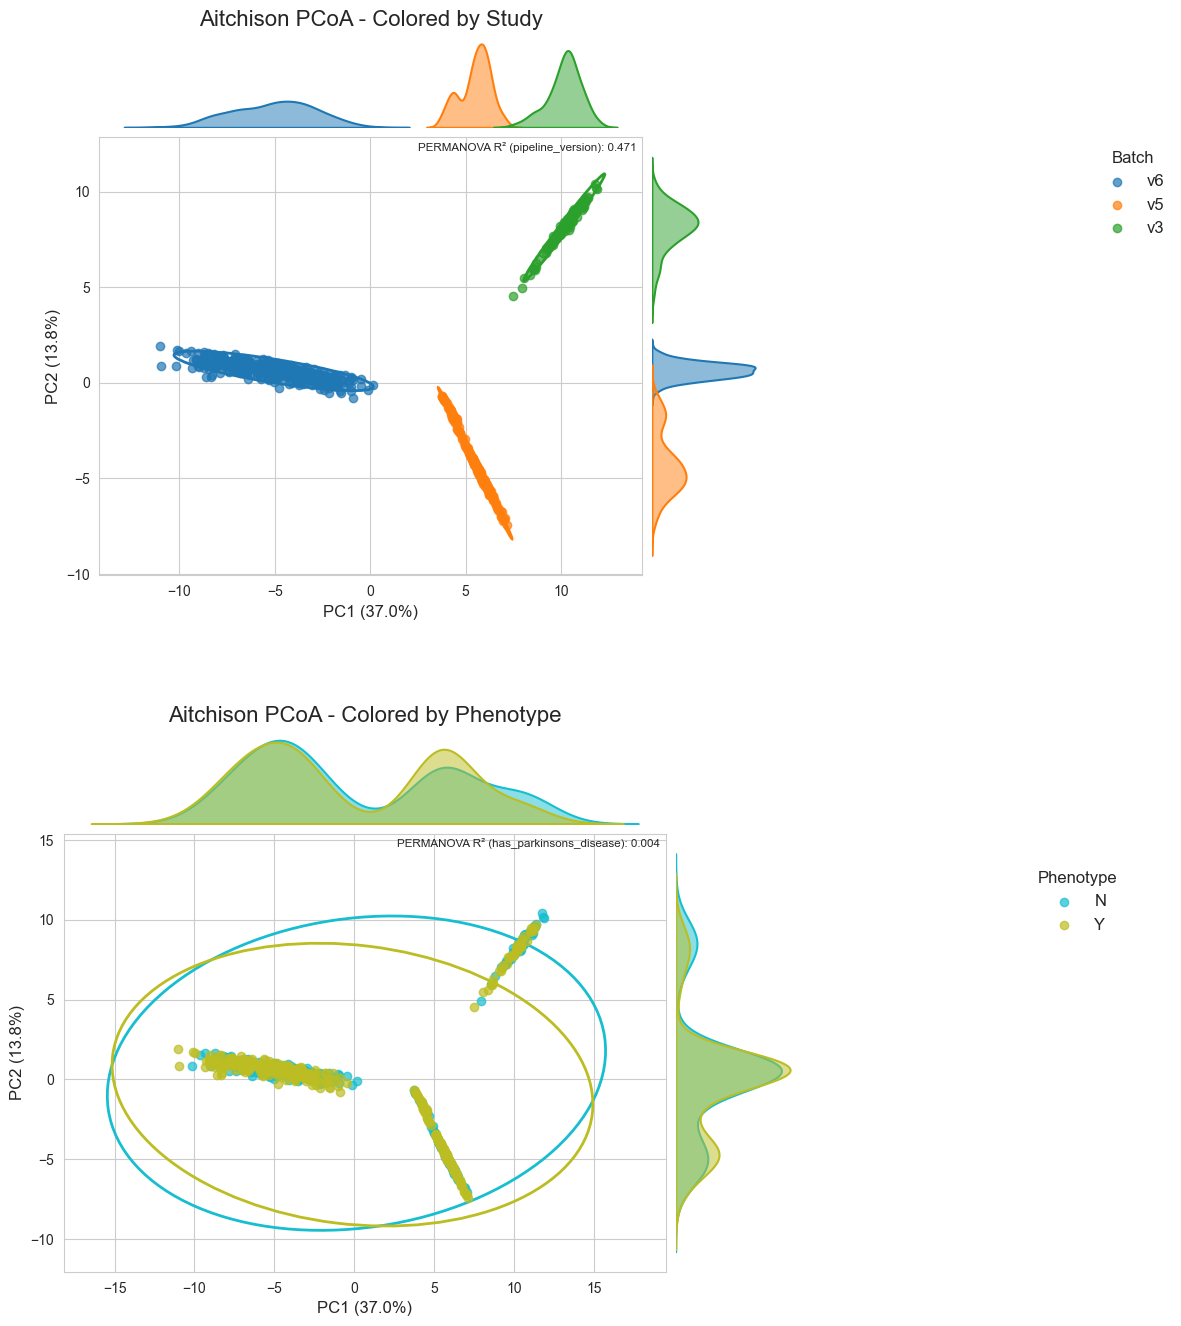

In [7]:
# Define figure
from abaco.dataloader import DataTransform

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

data_clr = DataTransform(df_parkinson, factors=[id_col, batch_col, bio_col], count=True)

data_pcoa, data_exp = pcoa_aitchison(
    data_clr, sample_label=id_col, batch_label=batch_col, bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False,
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Batch",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.8, 0.82),
    fontsize=12,
    title_fontsize=12,
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False,
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Phenotype",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.78, 0.37),
    fontsize=12,
    title_fontsize=12,
)

fig.subplots_adjust(right=0.85)

plt.show()

In [8]:
from abaco.ABaCo import metaABaCo
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create ABaCo model
abaco_model = metaABaCo(
    data=df_parkinson,
    n_bios=df_parkinson[bio_col].nunique(),
    bio_label=bio_col,
    n_batches=df_parkinson[batch_col].nunique(),
    batch_label=batch_col,
    n_features=df_parkinson.select_dtypes(include="number").shape[1],
    # prior="VMM",
    device=device,
    epochs=[1000, 2000, 1000],
)

abaco_model.fit(
    seed=42,
    w_cluster_penalty=0.1,  # 0.1
    phase_1_vae_lr=1e-3,  # 1e-3
    phase_2_vae_lr=1e-3,  # 1e-3
    phase_3_vae_lr=1e-7,  # 1e-7
    adv_lr=1e-4,  # 1e-4
    disc_lr=1e-4,
)  # 1e-4

Training: VAE for learning meaningful embeddings: 100%|██████████| 1000/1000 [00:25<00:00, 38.67it/s, bio_penalty=0.2297, clustering_loss=0.0066, elbo=86.9493, epoch=999/1001, vae_loss=87.1856] 
Training: Embeddings batch effect correction using adversrial training: 100%|██████████| 2000/2000 [01:08<00:00, 29.11it/s, adv_loss=-0.8494, bio_penalty=0.2636, clustering_loss=0.0066, disc_loss=0.8494, elbo=86.8188, epoch=1999/2001, vae_loss=87.0889]  
Training: VAE decoder with masked batch labels: 100%|██████████| 1000/1000 [00:20<00:00, 49.38it/s, cycle_loss=0.0000, epoch=1000/1000, vae_loss=266.7728]


/Users/anglup/GitHub/mgnipy/.venv/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_51436/127281214.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


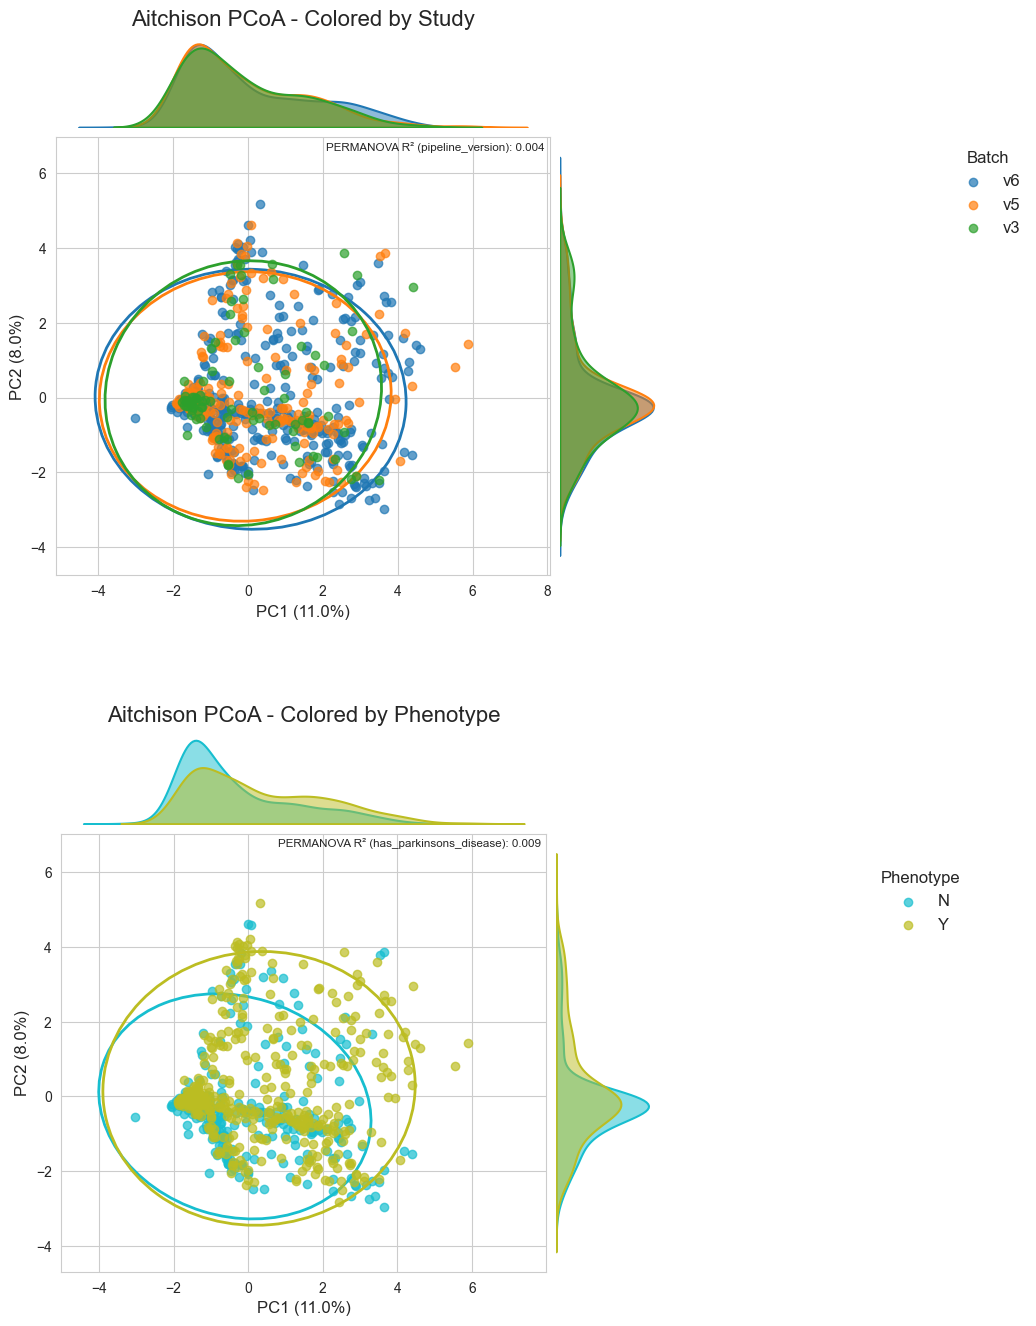

In [9]:
# Reconstruct the dataset using the trained ABaCo model
corrected_dataset = abaco_model.correct(seed=42)

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

corrected_data_clr = DataTransform(
    corrected_dataset, factors=[id_col, batch_col, bio_col], count=True
)

data_pcoa, data_exp = pcoa_aitchison(
    corrected_data_clr, sample_label=id_col, batch_label=batch_col, bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False,
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Batch",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.77, 0.82),
    fontsize=12,
    title_fontsize=12,
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False,
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Phenotype",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.745, 0.37),
    fontsize=12,
    title_fontsize=12,
)

fig.subplots_adjust(right=0.85)

plt.show()

In [10]:
import abaco.metrics as metrics

print("kBET results before batch correction:")
print(metrics.kBET(data_clr, batch_col))
print("\niLISI results before batch correction:")
print(metrics.iLISI_norm(data_clr, batch_col))
print("\nbatch ASW results before batch correction:")
print(1 - metrics.ASW(data_clr, batch_col))
print("\nbatch ARI results before batch correction:")
print(1 - metrics.ARI(data_clr, batch_col))

print("\n\nkBET results after batch correction:")
print(metrics.kBET(corrected_data_clr, batch_col))
print("\niLISI results after batch correction:")
print(metrics.iLISI_norm(corrected_data_clr, batch_col))
print("\nbatch ASW results after batch correction:")
print(1 - metrics.ASW(corrected_data_clr, batch_col))
print("\nbatch ARI results after batch correction:")
print(1 - metrics.ARI(corrected_data_clr, batch_col))

kBET results before batch correction:
0.007471980074719801

iLISI results before batch correction:
0.004610259622757962

batch ASW results before batch correction:
0.651118705750787

batch ARI results before batch correction:
0.47724063865900734


kBET results after batch correction:
0.8318804483188045

iLISI results after batch correction:
0.6327844602107708

batch ASW results after batch correction:
1.0235939528793097

batch ARI results after batch correction:
1.00499028780356


batch corrected. 

---
